## Variance in Linear Regression

This notebook explores how different levels of noise (variance) in the training data affect a linear regression model trained with SGD. For each of several noise levels we generate many independent datasets sampled from the same underlying signal, train one model per dataset, and look at the **spread** of the final loss and the learned parameters across those repeated trials — not just a single run per noise level.

In [4]:
import numpy as np

SLOPE = 3.5
INTERCEPT = 7.1

"""Signal to estimate"""
def f(x: np.ndarray) -> np.ndarray:
    return x*SLOPE + INTERCEPT

coefs = np.array([
    [SLOPE],
    [INTERCEPT]
])

## How the data is built

The `generate_dataset` function builds a stack of datasets with progressively higher variance along `axis=0`. Each dataset shares the same `x` samples and clean signal `y = f(x)`, but a different amount of Gaussian noise is added to `y`. The noise levels are equally spaced between `0` and `noise_upto`, so the first dataset in the stack is noise-free and the last one has the highest variance. The larger `noise_upto` is, the noisier (and more spread out) the final dataset becomes.

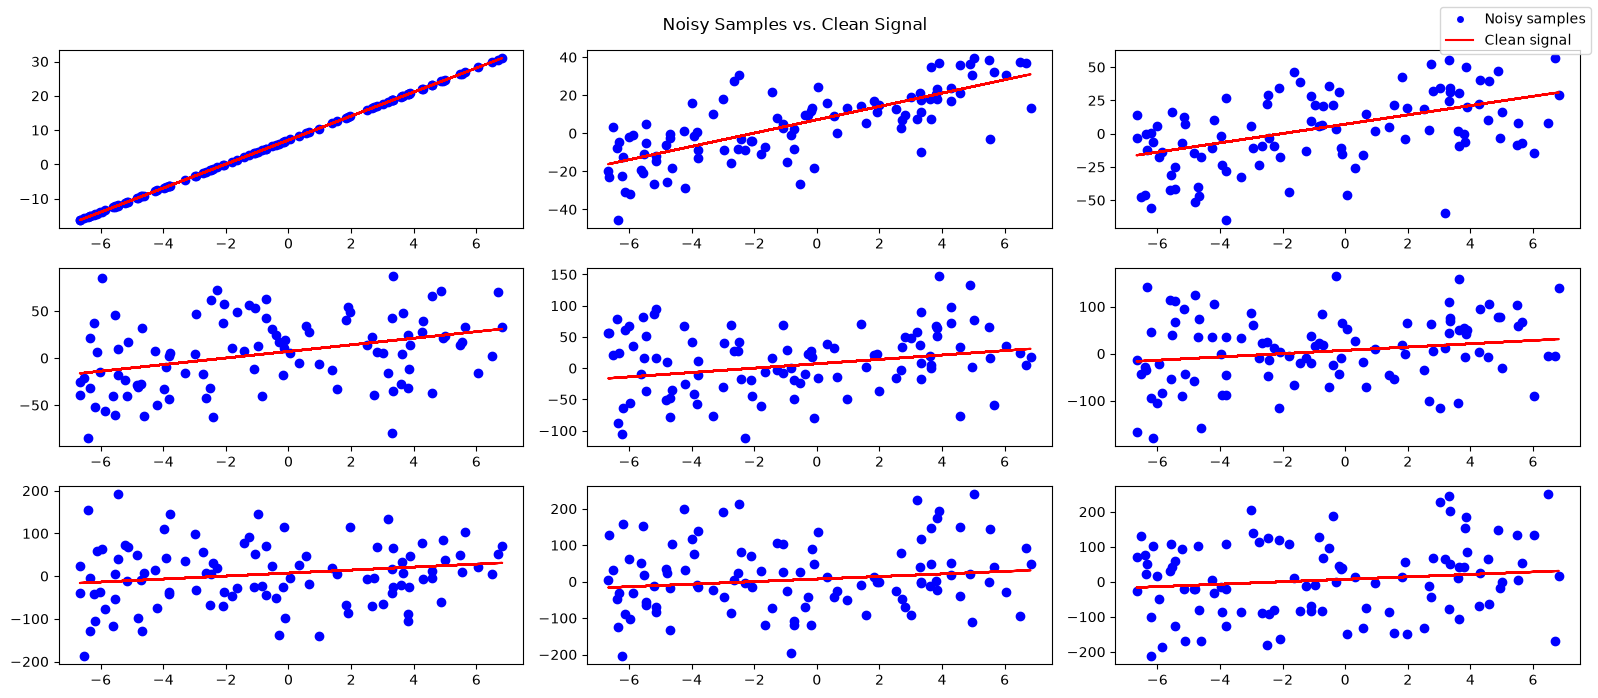

In [5]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from examples.helpers.dataset import generate_dataset
from examples.helpers.graph import generate_axs, plot_dataset, scatter_dataset

MIN = -7
MAX = 7
SEED = 777
DATASETS_SIZE = 9
SAMPLE_SIZE = 100
NOISE_UPTO = 100

X = generate_dataset(f, size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=NOISE_UPTO, min=MIN, max=MAX, seed=SEED)
X_clean = generate_dataset(f, size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=0, min=MIN, max=MAX, seed=SEED)

fig, axs = generate_axs(X.shape[0])
scatter_dataset(X, fig, axs)
plot_dataset(X_clean, fig, axs)

fig.suptitle("Noisy Samples vs. Clean Signal")
fig.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Noisy samples'),
    Line2D([0], [0], color='red', label='Clean signal'),
], loc='upper right')

fig.tight_layout()
plt.show()

## Training the models

For each noise level, `generate_noise_repeats` draws `N_REPEATS` independent datasets — same `x` samples, same signal, but freshly sampled Gaussian noise added to `y` each time. Every repeat gets its own `Trainer` (fresh `Sequential(Linear(1, 1))`, `MSELoss`, `SGD`, `CosineSchedule`) and is trained from scratch with `fit_model`.

`BATCH_SIZE` is set to `1` to measure each model's per-sample latency in isolation. The final parameters and loss history of every repeat, at every noise level, are collected into `all_params`, `all_train_loss` and `all_eval_loss` for the analysis below.

In [ ]:
from core.training import Trainer
from examples.helpers.dataset import generate_noise_repeats
from examples.helpers.train import create_trainer, fit_model, get_model_param, preprocess_dataloader, split_dataset

EPOCHS = 80
EVAL_STEP = 10
BATCH_SIZE = 1
N_REPEATS = 20
IN_FEATURE, OUT_FEATURE = 1, 1
MAX_LR, MIN_LR = 1e-2, 1e-4

all_params = []
all_train_loss = []   # (DATASETS_SIZE, N_REPEATS, REPEAT_EPOCHS)
all_eval_loss = []    # (DATASETS_SIZE, N_REPEATS, REPEAT_EPOCHS/EVAL_STEP)
noise_levels = np.linspace(0, NOISE_UPTO, DATASETS_SIZE)

for noise in noise_levels:
    level_params, level_train_loss, level_eval_loss = [], [], []
    repeats = generate_noise_repeats(f, N_REPEATS, SAMPLE_SIZE, noise, MIN, MAX, SEED)
    tr, te = split_dataset(repeats, split_ratio=0.9, axis=1)

    for sample_tr, sample_te in zip(tr, te):
        trainer = create_trainer(IN_FEATURE, OUT_FEATURE, MIN_LR, MAX_LR, EPOCHS)
        loader_tr, loader_te = preprocess_dataloader(sample_tr, sample_te, BATCH_SIZE)
        
        fit_model(trainer, loader_tr, loader_te, EPOCHS, EVAL_STEP)

        level_params.append(get_model_param(trainer.model))
        level_train_loss.append(trainer.train_loss)
        level_eval_loss.append(trainer.eval_loss)


    all_params.append(level_params)
    all_train_loss.append(level_train_loss)
    all_eval_loss.append(level_eval_loss)

all_params = np.array(all_params)
all_train_loss = np.array(all_train_loss) 
all_eval_loss = np.array(all_eval_loss) 


## Loss history

Instead of a single final loss per noise level, we now have `N_REPEATS` of them. We take the last evaluation loss of every repeat (`all_eval_loss[:, :, -1]`) and draw one boxplot per noise level, so both the typical loss and its spread across repeats are visible at once.

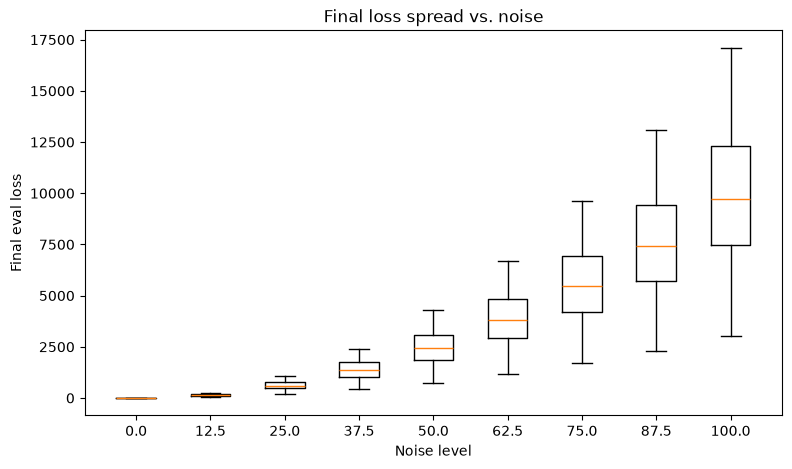

In [ ]:
final_eval_loss = all_eval_loss[:, :, -1]  # (DATASETS_SIZE, N_REPEATS)

fig, ax = plt.subplots(figsize=(DATASETS_SIZE, 5))
ax.boxplot(final_eval_loss.T, positions=noise_levels, widths=NOISE_UPTO/DATASETS_SIZE*0.6)
ax.set_xlabel("Noise level")
ax.set_ylabel("Final eval loss")
ax.set_title("Final loss spread vs. noise")
plt.show()

## Weights interpretation

Finally, we extract the learned weight and bias from every repeat at every noise level (`all_params[:, :, 0, 0, 0]` and `all_params[:, :, 1, 0, 0]`) and draw one boxplot per noise level for each parameter, with a dashed red line marking the true `SLOPE`/`INTERCEPT`. This shows not just how far the *average* estimate drifts as noise grows, but how much the estimate itself varies from one noisy sample to the next.

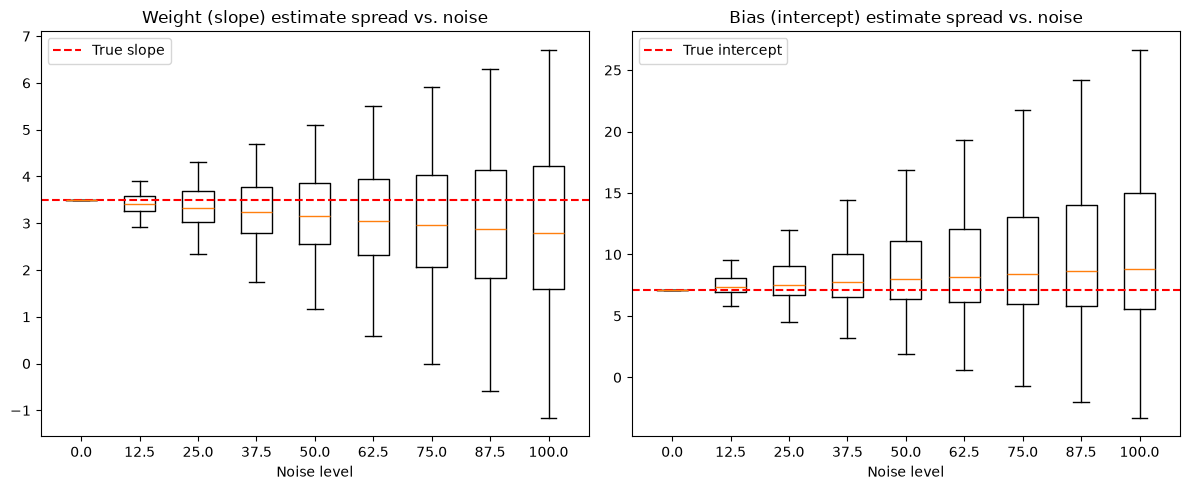

In [ ]:
fig, (ax_w, ax_b) = plt.subplots(1, 2, figsize=(12, 5))

weight_samples = all_params[:, :, 0, 0, 0]
bias_samples   = all_params[:, :, 1, 0, 0]

ax_w.boxplot(weight_samples.T, positions=noise_levels, widths=NOISE_UPTO/DATASETS_SIZE*0.6)
ax_w.axhline(SLOPE, color='red', linestyle='--', label='True slope')
ax_w.set_title("Weight (slope) estimate spread vs. noise")
ax_w.set_xlabel("Noise level")
ax_w.legend()

ax_b.boxplot(bias_samples.T, positions=noise_levels, widths=NOISE_UPTO/DATASETS_SIZE*0.6)
ax_b.axhline(INTERCEPT, color='red', linestyle='--', label='True intercept')
ax_b.set_title("Bias (intercept) estimate spread vs. noise")
ax_b.set_xlabel("Noise level")
ax_b.legend()

fig.tight_layout()
plt.show()

## Conclusion

Across all noise levels, the model recovers a slope and intercept centered close to the true `SLOPE`/`INTERCEPT`, confirming that SGD converges to an unbiased estimate on average even under heavy noise. What changes with noise is not the *center* of the estimates but their **spread**: as `noise` grows, both the final eval loss and the learned parameters (weight and bias) show wider boxplots across repeats, meaning any single trained model becomes a less reliable estimate of the true signal.

This distinction matters in practice — a single run at high noise can land close to the true parameters purely by chance, or far from them just as easily. Repeating training across many independently sampled datasets, as done here with `N_REPEATS`, is what reveals this variance; it would be invisible from a single trial per noise level.
